# Developing a Trading Strategy using NLP and Sentiment Analysis

This project aims to use Sentiment Analysis on the headlines obtained to make trade calls.

**Dataset is derived from the following scources:**

News headlines data compiled from RSS feeds of several news websites: This news headlines data is complied by different news website and contains the most financially relevant news filtered by human editors. For the purpose of this study, we will only look at the headline, not the details in the story. Another important characteristic of this dataset is that the relevant tickers in the story are extracted. Our dataset contains 82,643 headlines from to 2011-05-02 to 2018-12-28

Yahoo finance website for the stock return: (The return data can be obtained from other website such as yahoo finance)

## 1. Data Preparation

Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json
import zipfile
import os.path
import sys#NLP libraries
from textblob import TextBlob
import spacy
import nltk
import warnings
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
import csv

#Run the command python -m spacy download en_core_web_sm to download this
#https://spacy.io/models
#import en_core_web_lg
#nlp = en_core_web_lg.load()

#Libraries for processing the news headlines
from lxml import etree
import json
from io import StringIO
from os import listdir
from os.path import isfile, join
from pandas.tseries.offsets import BDay
from scipy.stats.mstats import winsorize
from copy import copy

# Libraries for Classification for modeling the sentiments
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras package for the deep learning model for the sentiment prediction.
# from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences
# from keras.models import Sequential
# from keras.layers import Dense, Flatten, LSTM, Dropout, Activation
# from keras.layers.embeddings import Embedding

# Load libraries
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
from datetime import date,datetime
import matplotlib.pyplot as plt
import yfinance as yf

#Additional Libraries
import json
import zipfile
import os.path
import sys

# import backtrader as bt
# import backtrader.indicators as btind
# import backtrader.analyzers as btanalyzers


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
data = pd.read_csv("Step2.2_ReturnData.csv")

In [3]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,21909.000000,21909.000000,21909.000000,21909.000000,2.190900e+04,21909.000000,21909.000000
mean,185.865993,187.770553,183.773477,185.831468,2.288962e+07,0.002480,0.000776
std,270.960100,273.503974,267.916842,270.768116,3.362882e+07,0.033435,0.068566
min,6.960000,7.180000,6.930000,7.020000,7.900000e+03,0.000000,0.000000
25%,41.870000,42.260000,41.540000,41.870000,4.140500e+06,0.000000,0.000000
50%,79.250000,79.870000,78.520000,79.290000,1.047320e+07,0.000000,0.000000
75%,210.890000,214.540000,207.740000,211.010000,2.801470e+07,0.000000,0.000000
max,2038.110000,2050.500000,2013.000000,2039.510000,5.735764e+08,0.800000,7.000000


In [5]:
def missingness(df):
  dic = {}
  for col in df.columns:
    no = df[col].isnull().sum()
    percentage = 1- (no/len(df[col]) *100)
    dic[col] = percentage

  names = list(dic.keys())
  values = list(dic.values())
  plt.figure(figsize=(10, 6))
  plt.bar(range(len(dic)), values, tick_label=names, color='skyblue')
  plt.xlabel('Columns')
  plt.ylabel('Percentage of Data Available')
  plt.title('Missing Values Percentage by Column')
  plt.xticks(rotation=45)
  plt.show()






Ensuring the data is suitable without missing values.

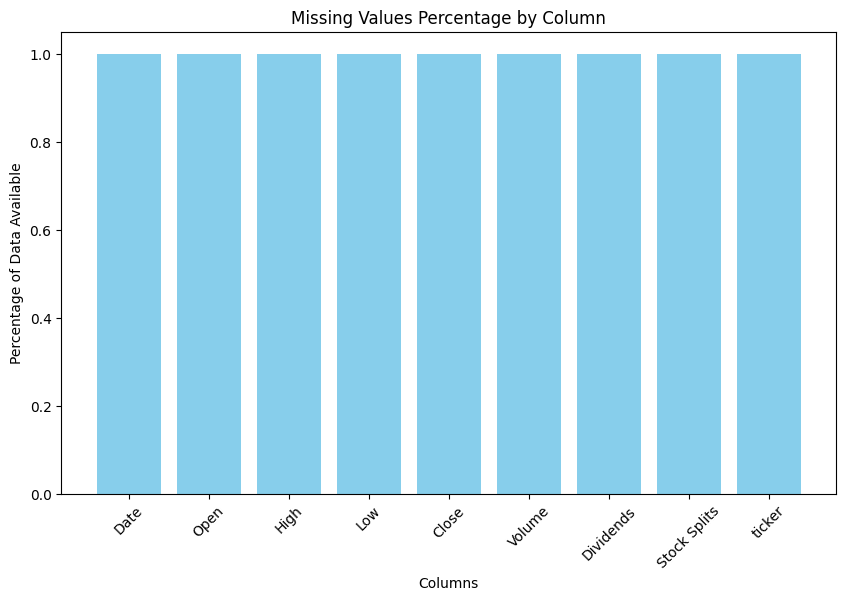

In [6]:

missingness(data)

In [7]:
data.ticker.unique()

array(['AAPL', 'MSFT', 'AMZN', 'GOOG', 'FB', 'WMT', 'JPM', 'TSLA', 'NFLX',
       'ADBE'], dtype=object)

AAPL: Apple Inc.
MSFT: Microsoft Corporation
AMZN: Amazon.com, Inc.
GOOG: Alphabet Inc. (Google)
FB: Meta Platforms, Inc. (formerly Facebook, Inc.)
WMT: Walmart Inc.
JPM: JPMorgan Chase & Co.
TSLA: Tesla, Inc.
NFLX: Netflix, Inc.
ADBE: Adobe Inc.

### 1. Data Preprocessing

Organising the headlines data to associate it with the respective ticker.

In [8]:
z = zipfile.ZipFile("Raw Headline Data.zip", "r")
testFile=z.namelist()[10]
fileData= z.open(testFile).read()

In [9]:
def jsonParser(json_data):
    xml_data = json_data['content']

    tree = etree.parse(StringIO(xml_data), parser=etree.HTMLParser())

    headlines = tree.xpath("//h4[contains(@class, 'media-heading')]/a/text()")
    assert len(headlines) == json_data['count']

    main_tickers = list(map(lambda x: x.replace('/symbol/', ''), tree.xpath("//div[contains(@class, 'media-left')]//a/@href")))
    assert len(main_tickers) == json_data['count']
    final_headlines = [''.join(f.xpath('.//text()')) for f in tree.xpath("//div[contains(@class, 'media-body')]/ul/li[1]")]
    if len(final_headlines) == 0:
        final_headlines = [''.join(f.xpath('.//text()')) for f in tree.xpath("//div[contains(@class, 'media-body')]")]
        final_headlines = [f.replace(h, '').split('\xa0')[0].strip() for f,h in zip (final_headlines, headlines)]
    return main_tickers, final_headlines

In [11]:
dataa = None
data_df_news = []
ret = []
ret_f = []
with zipfile.ZipFile("Raw Headline Data.zip", "r") as z:
    for filename in z.namelist():
        #print(filename)
        try:
            #print('Running {}'.format(filename))
            with z.open(filename) as f:
                dataa = f.read()
                json_data = json.loads(dataa)
            if json_data.get('count', 0)> 10:
                #Step 1: Parse the News Jsons
                main_tickers, final_headlines = jsonParser(json_data)
                if len(final_headlines) != json_data['count']:
                    continue
                #Step 2: Prepare Future and Event Return and assign Future and Event return for each ticker.
                file_date = filename.split('/')[-1].replace('.json', '')
                file_date = date(int(file_date[:4]), int(file_date[5:7]), int(file_date[8:]))
               #Step 3: Merge all the data in a data frame
                df_dict = {'ticker': main_tickers,
                           'headline': final_headlines,
                           'date': [file_date] * len(main_tickers)
                           }
                df_f = pd.DataFrame(df_dict)
                data_df_news.append(df_f)
        except:
            pass

In [12]:
data_df_news=pd.concat(data_df_news)
data_df_news.head(2)

,ticker,headline,date
0,DVA,Davita (NYSE:DVA): EPS of $0.96 beats by $0.01...,2011-05-02
1,CGNX,Cognex (NASDAQ:CGNX): EPS of $0.32 beats by $0...,2011-05-02


In [13]:
#Computing the return
data['ret_curr'] = data['Close'].pct_change()
#Computing the event return
data['eventRet'] = data['ret_curr'] + data['ret_curr'].shift(-1) + data['ret_curr'].shift(1)
data.reset_index(level=0, inplace=True)
data['date'] = pd.to_datetime(data['Date']).apply(lambda x: x.date())

Having obtained the headlines we now merge it with the existing data using the merge command.

In [14]:
merged_df = pd.merge(data_df_news, data, how="left", left_on=['date','ticker'],right_on=['date','ticker'])

In [15]:
ticker = list(data.ticker.unique())
merged_df = merged_df[merged_df['ticker'].isin(ticker)]
merged_df = merged_df[['ticker','headline','date','eventRet','Open','Close']]

In [16]:
merged_df

,ticker,headline,date,eventRet,Open,Close
5,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.017650,196.57,201.19
11,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,-0.013003,34.03,33.88
74,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.019823,20.40,20.63
77,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.019823,20.40,20.63
86,MSFT,,2011-05-10,-0.019823,20.40,20.63
...,...,...,...,...,...,...
122202,ADBE,Jefferies rates Adobe (NASDAQ:ADBE) at Buy and...,2019-12-13,NaN,NaN,NaN
122256,TSLA,Tesla (TSLA +6.4%) is riding higher after Cred...,2019-12-16,NaN,NaN,NaN
122259,AAPL,Cleveland Research says its checks show strong...,2019-12-16,NaN,NaN,NaN
122385,TSLA,Tesla (TSLA +3.1%) carved out a new intraday h...,2019-12-18,NaN,NaN,NaN


In [17]:
merged_df.dropna().to_csv('Preprocessed_data.csv',sep=',',index=False)

###Downloading the preprocessed data

In [2]:
data = pd.read_csv('Preprocessed_data.csv')
data = data.dropna()

In [3]:
data

,ticker,headline,date,eventRet,Open,Close
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.017650,196.57,201.19
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,-0.013003,34.03,33.88
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.019823,20.40,20.63
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.019823,20.40,20.63
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,-0.006607,204.22,206.07
...,...,...,...,...,...,...
2763,TSLA,"Responding to a comment on Twitter, Elon Musk ...",2018-12-24,0.041608,313.50,295.39
2764,AMZN,Amazon (NASDAQ:AMZN) is among the companies th...,2018-12-24,0.013062,1346.00,1343.96
2765,AAPL,Chinese companies urge employees to boycott (N...,2018-12-24,0.005634,145.22,143.92
2766,TSLA,Elon Musk tweets that Tesla's (NASDAQ:TSLA) Su...,2018-12-26,-0.002856,300.00,326.09


### 2. Sentiment Analysis based on the headlines

**2.1 Text Blob**

TextBlob is a simple and intuitive Python library for processing textual data. One of its most popular features is sentiment analysis, which allows users to gauge the sentiment of a given text (positive, negative, or neutral) by analyzing the words and structure of the text.

TextBlob uses a lexicon-based approach, employing pre-trained word polarity and subjectivity dictionaries (e.g., Pattern Analyzer). It does not require training on a labeled dataset. With its simple syntax, TextBlob is user-friendly and suitable for beginners in natural language processing (NLP).



In [4]:
## Text Blob
text = data.headline[0]
text

'Whole Foods (WFMI) -5.2% following a downgrade to "hold" from "buy" at Jefferies. Gas prices are the culprit, writes Scott Mushkin, claiming at $4/gallon, even the affluent who patronize the upscale grocery begin to take notice. Whole Foods announces earnings after Wednesday\'s close.'

In [5]:
data['sentiment_tb'] = [TextBlob(s).sentiment.polarity for s in data['headline']]

CORRELATION BETWEEN EVENT RETURN AND TEXTBLOB SENTIMENT ANALYSIS: [[1.         0.04274934]
 [0.04274934 1.        ]]


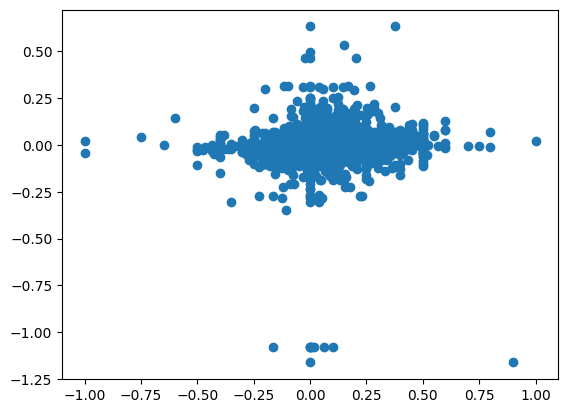

In [6]:
plt.scatter(data['sentiment_tb'],data['eventRet'])
corr = np.corrcoef(data['sentiment_tb'],data['eventRet'])
print("CORRELATION BETWEEN EVENT RETURN AND TEXTBLOB SENTIMENT ANALYSIS: {}".format(corr))

The general correlation between Event Return and sentiment analysis suggests that there is barely any correlation between it as it is very close to 0. (0.042)


The sentiment polarity is a number between -1 (Very Negative) and +1 (Very Positive). We apply this on all headline we have in the data processed in the previous step. Let us compute the sentiment for all the headlines in the data

Example of statements that are very negative

In [8]:
for i in data[data['sentiment_tb']==-1].headline:
  print(i)

Online 8,000-lb. gorilla Amazon (AMZN +0.1%) can make life miserable for prescription drug sellers in a variety of ways according to Bloomberg.
Netflix (NFLX -4.3%) ended up with its worst day in weeks after Deutsche Bank sounded some cautions ahead of Monday's afternoon earnings release.


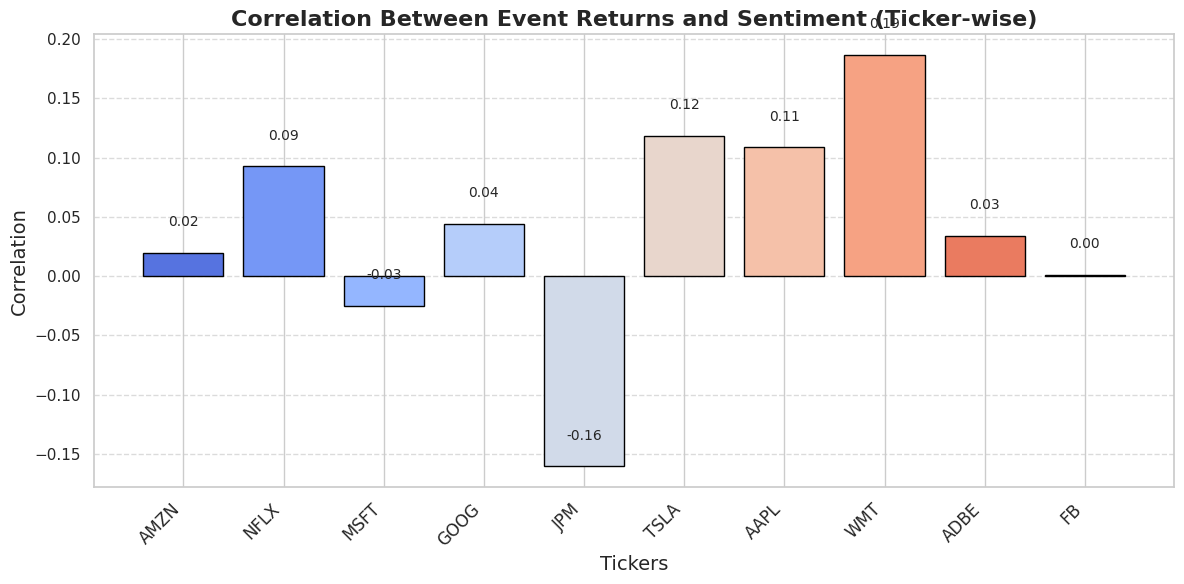

In [9]:
tickers = list(data['ticker'].unique())
correlation_sa = []
for i in tickers:
  df = data[data['ticker']==i]
  correlation_sa.append(df['eventRet'].corr(df['sentiment_tb']))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot with enhanced colors and labels
bar_colors = sns.color_palette("coolwarm", len(tickers))
bars = plt.bar(tickers, correlation_sa, color=bar_colors, edgecolor='black')

# Add labels and title
plt.title("Correlation Between Event Returns and Sentiment (Ticker-wise)", fontsize=16, fontweight='bold')
plt.xlabel("Tickers", fontsize=14)
plt.ylabel("Correlation", fontsize=14)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45, ha="right", fontsize=12)

# Annotate each bar with its value
for bar, correlation in zip(bars, correlation_sa):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,  # Position slightly above the bar
             f"{correlation:.2f}",
             ha="center", va="bottom", fontsize=10)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

Having looked at the correlation between individual tickers event returns and sentiment analysis we could notice certain companies such as WMT, JPM, TSLA and AAPL have a positive correlation greater than 0.1.

**2.2 BERT**

The DistilBERT Base Uncased Fine-Tuned SST-2 model is a lightweight, efficient version of BERT, fine-tuned specifically for sentiment analysis on the Stanford Sentiment Treebank v2 (SST-2) dataset. Designed for binary classification tasks, it predicts whether a given text expresses positive or negative sentiment. The model is uncased, meaning it ignores case distinctions, and uses a tokenizer compatible with its smaller vocabulary. With 66 million parameters, it is smaller, faster, and more deployable than the original BERT while retaining most of its language understanding capabilities. Ideal for analyzing reviews, social media posts, and customer feedback, the model delivers high accuracy and is suitable for real-time applications.

In [26]:
from transformers import pipeline

# Load a pretrained sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Example text data
texts = [
    "I love this product! It works perfectly.",
    "This is the worst experience I've ever had.",
    "It's okay, nothing special."
]

# Analyze sentiment
results = sentiment_analyzer(texts)

# Print the results
for text, result in zip(texts, results):
    print(f"Text: {text}")
    print(f"Sentiment: {result['label']}, Score: {result['score']:.4f}")
    print()


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


Text: I love this product! It works perfectly.
Sentiment: POSITIVE, Score: 0.9999

Text: This is the worst experience I've ever had.
Sentiment: NEGATIVE, Score: 0.9998

Text: It's okay, nothing special.
Sentiment: NEGATIVE, Score: 0.8190



In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [11]:

texts = [
    "I love this product! It works perfectly.",
    "This is the worst experience I've ever had.",
    "It's okay, nothing special."
]
inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=512)

from torch.nn.functional import softmax

outputs = model(**inputs)
probs = softmax(outputs.logits, dim=1)
labels = ["NEGATIVE", "POSITIVE"]
for i, text in enumerate(texts):
    print(f"Text: {text}")
    print(f"Sentiment: {labels[probs[i].argmax()]}, Score: {probs[i].max().item():.4f}")


Text: I love this product! It works perfectly.
Sentiment: POSITIVE, Score: 0.9999
Text: This is the worst experience I've ever had.
Sentiment: NEGATIVE, Score: 0.9998
Text: It's okay, nothing special.
Sentiment: NEGATIVE, Score: 0.8190


In [12]:
inputs

{'input_ids': tensor([[ 101, 1045, 2293, 2023, 4031,  999, 2009, 2573, 6669, 1012,  102,    0,
            0],
        [ 101, 2023, 2003, 1996, 5409, 3325, 1045, 1005, 2310, 2412, 2018, 1012,
          102],
        [ 101, 2009, 1005, 1055, 3100, 1010, 2498, 2569, 1012,  102,    0,    0,
            0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]])}

In [30]:
probs[0].max()-probs[0].min()

tensor(0.9998, grad_fn=<SubBackward0>)

In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import torch

# Load pretrained model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Tokenize input texts in batches to handle large datasets efficiently
batch_size = 10  # Adjust batch size based on memory capacity
sentiment_scores = []

for i in range(0, len(data), batch_size):
    batch_texts = list(data['headline'][i:i+batch_size])  # Get batch of headlines
    inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=512)  # Max length is 512
    outputs = model(**inputs)
    logits = outputs.logits  # Raw scores for each class
    probs = softmax(logits, dim=1)  # Convert to probabilities
    scores = probs[:, 1] - probs[:, 0]  # Positive probability - Negative probability
    sentiment_scores.extend(scores.tolist())  # Collect scores for each batch

# Add sentiment scores to the DataFrame
data['sentiment_bert'] = sentiment_scores

CORRELATION BETWEEN EVENT RETURN AND TEXTBLOB SENTIMENT ANALYSIS: 0.10828005489503358


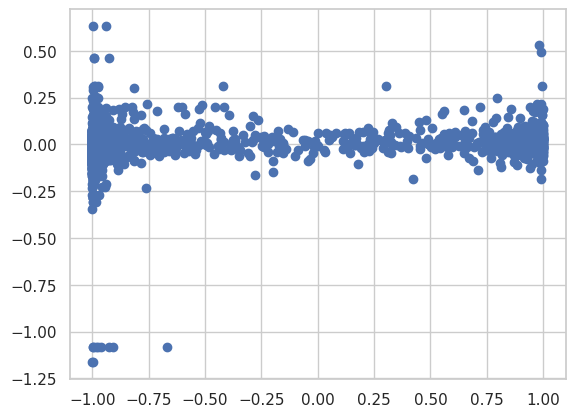

In [25]:
plt.scatter(data['sentiment_bert'],data['eventRet'])
corr = data['sentiment_bert'].corr(data['eventRet'])
print("CORRELATION BETWEEN EVENT RETURN AND BERT SENTIMENT ANALYSIS: {}".format(corr))

The correlation between event return and bert sentiment analysis is 0.108 which is greater than found with respect to TEXTBLOB.

In [26]:
data.dropna().to_csv('Preprocessed_data_with_bert.csv',sep=',',index=False)

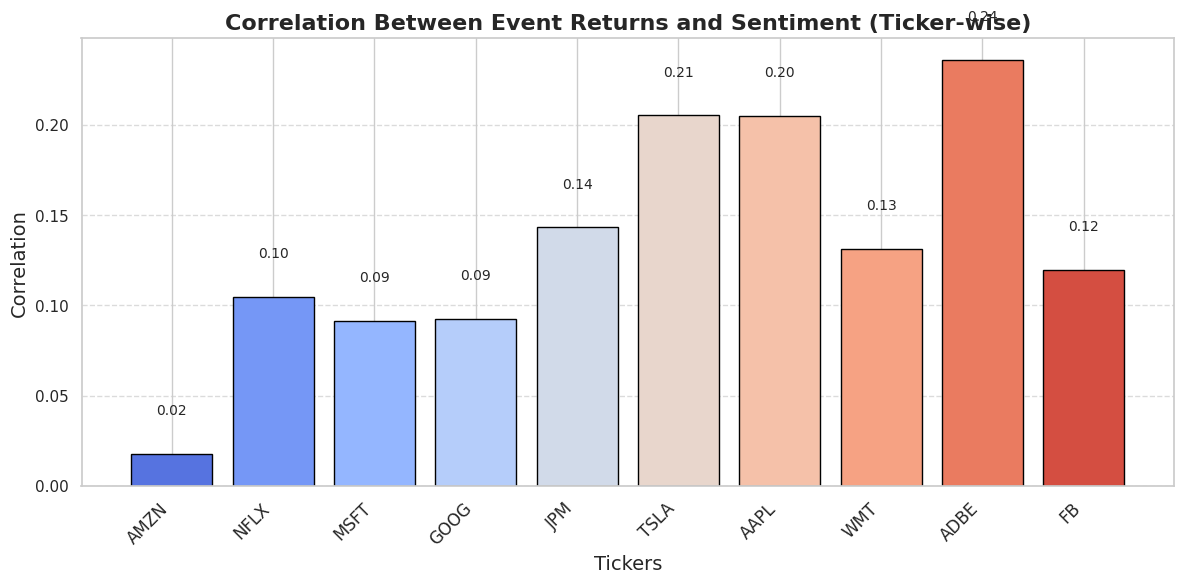

In [27]:
tickers = list(data['ticker'].unique())
correlation_sa = []
for i in tickers:
  df = data[data['ticker']==i]
  correlation_sa.append(df['eventRet'].corr(df['sentiment_bert']))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot with enhanced colors and labels
bar_colors = sns.color_palette("coolwarm", len(tickers))
bars = plt.bar(tickers, correlation_sa, color=bar_colors, edgecolor='black')

# Add labels and title
plt.title("Correlation Between Event Returns and Sentiment (Ticker-wise)", fontsize=16, fontweight='bold')
plt.xlabel("Tickers", fontsize=14)
plt.ylabel("Correlation", fontsize=14)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45, ha="right", fontsize=12)

# Annotate each bar with its value
for bar, correlation in zip(bars, correlation_sa):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,  # Position slightly above the bar
             f"{correlation:.2f}",
             ha="center", va="bottom", fontsize=10)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

As we notice some of the cprrelation with individual tickers seems to exceed 0.2 which indicates low positive correlation.

### **3. Developing a Trading Strategy.**

The sentiment data can be used in different ways for the trading strategy. Sentiment scores can be used as a directional signal and ideally create a long-short portfolio, by buying the stocks with positive score and selling the stocks with negative score. The sentiments can also be used as additional features over and above other features(such as correlated stocks, technical indicators) in a supervised learning model to predict the price or come up with a trading strategy.

In the trading strategy in this case study we buy and sell stock as per the current stock sentiments :

Buy a stock when the change in sentiment score (Current sentiment score - previous sentiment score) is greater than .5 and sell a stock when the change in sentiment score is less than -.5.
Additionally, we check for 15 days moving average while buying and selling and buy or sell in a unit of 100.
Obviusly, there can be many ways to create the trading strategy based in sentiments, by varying the threshold, or changing the number of units based on the initial cash available.


**Setting up the strategy**
Here we use backtrader which is a Python based API for writing and backtesting trading strategy. . Backtrader allows you to focus on writing reusable trading strategies, indicators and analyzers instead of having to spend time building infrastructure. we have a convenient framework to backtest and write our trading strategy. We used the Quickstart code in the docs (i.e. Refer to https://www.backtrader.com/docu/quickstart/quickstart/) as a base and modified it to include the sentiment scores.

We imlement a simple strategy to buy if the previous day’s sentiment score increases by 0.5 from the last day and sell if it decreases by 0.5.

The following function contains two classes:

Sentiment:
SentimentStrat: The "next" function of this class implements the actual trading strategy.

In [2]:
data = pd.read_csv('Preprocessed_data_with_bert.csv')

In [15]:
!pip install backtrader
import backtrader as bt
import backtrader.indicators as btind
import backtrader.analyzers as btanalyzers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.5 MB/s eta 0:00:00


In [16]:


class Sentiment(bt.Indicator):
    lines = ('sentiment',)
    plotinfo = dict(
        plotymargin=0.5,
        plothlines=[0],
        plotyticks=[1.0, 0, -1.0])

    def next(self):
        self.sentiment = 0.0
        self.date = self.data.datetime
        date = bt.num2date(self.date[0]).date()
        prev_sentiment = self.sentiment
        if date in date_sentiment:
            self.sentiment = date_sentiment[date]
        self.lines.sentiment[0] = self.sentiment


class SentimentStrat(bt.Strategy):
    params = (
        ('period', 15),
        ('printlog', True),
    )

    def log(self, txt, dt=None, doprint=False):
        ''' Logging function for this strategy'''
        if self.params.printlog or doprint:
            dt = dt or self.datas[0].datetime.date(0)
            print('%s, %s' % (dt.isoformat(), txt))

    def __init__(self):
        # Keep a reference to the "close" line in the data[0] dataseries
        self.dataclose = self.datas[0].close
        # Keep track of pending orders
        self.order = None
        self.buyprice = None
        self.buycomm = None
        self.sma = bt.indicators.SimpleMovingAverage(
            self.datas[0], period=self.params.period)
        self.date = self.data.datetime
        self.sentiment = None
        Sentiment(self.data)
        self.plotinfo.plot = False


    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            # Buy/Sell order submitted/accepted to/by broker - Nothing to do
            return

        # Check if an order has been completed
        # Attention: broker could reject order if not enough cash
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(
                    'BUY EXECUTED, Price: %.2f, Cost: %.2f, Comm %.2f' %
                    (order.executed.price,
                     order.executed.value,
                     order.executed.comm))
                self.buyprice = order.executed.price
                self.buycomm = order.executed.comm
            else:  # Sell
                self.log('SELL EXECUTED, Price: %.2f, Cost: %.2f, Comm %.2f' %
                         (order.executed.price,
                          order.executed.value,
                          order.executed.comm))

            self.bar_executed = len(self)

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')

        # Write down: no pending order
        self.order = None

    def notify_trade(self, trade):
        if not trade.isclosed:
            return

        self.log('OPERATION PROFIT, GROSS %.2f, NET %.2f' %
                 (trade.pnl, trade.pnlcomm))

    ### Main Strat ###
    def next(self):
        date = bt.num2date(self.date[0]).date()
        prev_sentiment = self.sentiment
        if date in date_sentiment:
            self.sentiment = date_sentiment[date]

        # Check if an order is pending. if yes, we cannot send a 2nd one
        if self.order:
            return
        # If not in the market and previous sentiment not none
        if not self.position and prev_sentiment:
            # buy if current close more than sma AND sentiment increased by >= 0.5
            if self.dataclose[0] > self.sma[0] and self.sentiment - prev_sentiment >= 0.5:
                self.log('Previous Sentiment %.2f, New Sentiment %.2f BUY CREATE, %.2f' % (prev_sentiment, self.sentiment, self.dataclose[0]))
                self.order = self.buy()

        # Already in the market and previous sentiment not none
        elif prev_sentiment:
            # sell if current close less than sma AND sentiment decreased by >= 0.5
            if self.dataclose[0] < self.sma[0] and self.sentiment - prev_sentiment <= -0.5:
                self.log('Previous Sentiment %.2f, New Sentiment %.2f SELL CREATE, %.2f' % (prev_sentiment, self.sentiment, self.dataclose[0]))
                self.order = self.sell()

    def stop(self):
        self.log('(MA Period %2d) Ending Value %.2f' %
                 (self.params.period, self.broker.getvalue()), doprint=True)






**Function for running the trading strategy**
Now, we write a generic function to run the strategy for any stock. We specified the “ticker” stock feeds to be pulled from Yahoo Finance, set an initial amount of $100,000, a fixed size of 100 lots per trade.

In [12]:
def run_strategy(ticker, start, end):
    print(ticker)
    ticker = yf.Ticker(ticker)
    df_ticker = ticker.history(start = start, end = end)

    cerebro = bt.Cerebro()
    # Add the data
    cerebro.addstrategy(SentimentStrat)
    data = bt.feeds.PandasData(dataname=df_ticker)
    cerebro.adddata(data)
    start = 100000.0
    cerebro.broker.setcash(start)
    cerebro.addsizer(bt.sizers.FixedSize, stake=100)
    print('Starting Portfolio Value: %.2f' % start)
    plt.rcParams['figure.figsize']=[10,6]
    plt.rcParams["font.size"]="12"
    cerebro.run()
    cerebro.plot(volume=False, iplot=True, plotname= ticker)
    end = cerebro.broker.getvalue()
    print('Start Portfolio value: %.2f\nFinal Portfolio Value: %.2f\nProfit: %.2f\n' \
          % (start, end, end - start))
    return float(df_ticker['Close'][0]), (end - start)

In [10]:


def extract_buy_sell_dates_and_plot_tb(data, ticker, start_date, end_date):
    # Ensure 'date' is a datetime object
    data['date'] = pd.to_datetime(data['date'])

    # Filter data by ticker and date range
    filtered_data = data[
        (data['ticker'] == ticker) &
        (data['date'] >= pd.to_datetime(start_date)) &
        (data['date'] <= pd.to_datetime(end_date))
    ].sort_values('date')

    filtered_data = filtered_data[['date', 'sentiment_tb', 'Close']]

    # Initialize buy and sell dates
    buy_dates = []
    sell_dates = []
    buy = False  # Tracks whether a "buy" has already occurred

    # Loop through the filtered data to detect buy/sell signals
    for i in range(1, len(filtered_data)):
        previous_date, previous_sentiment, previous_close = filtered_data.iloc[i - 1]
        current_date, current_sentiment, current_close = filtered_data.iloc[i]

        # Buy condition: sentiment increases significantly, and no active buy
        if (current_sentiment - previous_sentiment > 0.5) and not buy:
            buy_dates.append(current_date)
            buy = True
        # Sell condition: sentiment decreases significantly, and a buy is active
        elif (current_sentiment - previous_sentiment < -0.5) and buy:
            sell_dates.append(current_date)
            buy = False

    # Extract the first Close value for each buy and sell date
    buy_prices = filtered_data[filtered_data['date'].isin(buy_dates)].groupby('date')['Close'].first()
    sell_prices = filtered_data[filtered_data['date'].isin(sell_dates)].groupby('date')['Close'].first()

    # Plot the close prices for the specified ticker
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_data['date'], filtered_data['Close'], label=f'{ticker} Close Price', color='blue')

    # Highlight buy dates with red upward triangle markers
    plt.scatter(buy_prices.index, buy_prices.values, color='green', marker='^', label='Buy', zorder=5)

    # Highlight sell dates with red downward triangle markers
    plt.scatter(sell_prices.index, sell_prices.values, color='red', marker='v', label='Sell', zorder=5)

    # Customize the plot
    plt.title(f'{ticker} Close Prices with Buy and Sell Dates')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    # Show the plot
    plt.show()

In [3]:


def extract_buy_sell_dates_and_plot(data, ticker, start_date, end_date):
    # Ensure 'date' is a datetime object
    data['date'] = pd.to_datetime(data['date'])

    # Filter data by ticker and date range
    filtered_data = data[
        (data['ticker'] == ticker) &
        (data['date'] >= pd.to_datetime(start_date)) &
        (data['date'] <= pd.to_datetime(end_date))
    ].sort_values('date')

    filtered_data = filtered_data[['date', 'sentiment_bert', 'Close']]

    # Initialize buy and sell dates
    buy_dates = []
    sell_dates = []
    buy = False  # Tracks whether a "buy" has already occurred

    # Loop through the filtered data to detect buy/sell signals
    for i in range(1, len(filtered_data)):
        previous_date, previous_sentiment, previous_close = filtered_data.iloc[i - 1]
        current_date, current_sentiment, current_close = filtered_data.iloc[i]

        # Buy condition: sentiment increases significantly, and no active buy
        if (current_sentiment - previous_sentiment > 0.5) and not buy:
            buy_dates.append(current_date)
            buy = True
        # Sell condition: sentiment decreases significantly, and a buy is active
        elif (current_sentiment - previous_sentiment < -0.5) and buy:
            sell_dates.append(current_date)
            buy = False

    # Extract the first Close value for each buy and sell date
    buy_prices = filtered_data[filtered_data['date'].isin(buy_dates)].groupby('date')['Close'].first()
    sell_prices = filtered_data[filtered_data['date'].isin(sell_dates)].groupby('date')['Close'].first()

    # Plot the close prices for the specified ticker
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_data['date'], filtered_data['Close'], label=f'{ticker} Close Price', color='blue')

    # Highlight buy dates with red upward triangle markers
    plt.scatter(buy_prices.index, buy_prices.values, color='green', marker='^', label='Buy', zorder=5)

    # Highlight sell dates with red downward triangle markers
    plt.scatter(sell_prices.index, sell_prices.values, color='red', marker='v', label='Sell', zorder=5)

    # Customize the plot
    plt.title(f'{ticker} Close Prices with Buy and Sell Dates')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    # Show the plot
    plt.show()

In [9]:
tickers = data.ticker.unique()
tickers

array(['AMZN', 'NFLX', 'MSFT', 'GOOG', 'JPM', 'TSLA', 'AAPL', 'WMT',
       'ADBE', 'FB'], dtype=object)

**Trading for GOOGLE using BERT sentiment analysis**




In [12]:
ticker = 'GOOG'
date_sentiment=data[data['ticker'].isin([ticker])]
date_sentiment=date_sentiment[['date','sentiment_bert']]
date_sentiment['date']=pd.to_datetime(date_sentiment['date'], format='%Y-%m-%d').dt.date
date_sentiment=date_sentiment.set_index('date')['sentiment_bert']
date_sentiment=date_sentiment.to_dict()
run_strategy(ticker, start = '2012-01-01', end = '2018-12-12')
extract_buy_sell_dates_and_plot(data, ticker='GOOG', start_date='2012-01-01', end_date='2018-12-12')

GOOG
Starting Portfolio Value: 100000.00
2012-05-16, Previous Sentiment -1.00, New Sentiment 0.96 BUY CREATE, 15.61
2012-05-17, BUY EXECUTED, Price: 15.73, Cost: 1573.01, Comm 0.00
2012-10-18, Previous Sentiment 0.94, New Sentiment -1.00 SELL CREATE, 17.25
2012-10-19, SELL EXECUTED, Price: 17.51, Cost: 1573.01, Comm 0.00
2012-10-19, OPERATION PROFIT, GROSS 178.07, NET 178.07
2013-01-23, Previous Sentiment -1.00, New Sentiment 0.65 BUY CREATE, 18.40
2013-01-24, BUY EXECUTED, Price: 18.40, Cost: 1839.57, Comm 0.00
2013-04-16, Previous Sentiment 0.49, New Sentiment -1.00 SELL CREATE, 19.69
2013-04-17, SELL EXECUTED, Price: 19.53, Cost: 1839.57, Comm 0.00
2013-04-17, OPERATION PROFIT, GROSS 112.94, NET 112.94
2013-10-18, Previous Sentiment -0.99, New Sentiment 0.78 BUY CREATE, 25.10
2013-10-21, BUY EXECUTED, Price: 25.10, Cost: 2510.19, Comm 0.00
2014-04-23, Previous Sentiment 0.99, New Sentiment -0.99 SELL CREATE, 26.18
2014-04-24, SELL EXECUTED, Price: 26.34, Cost: 2510.19, Comm 0.00
201

<IPython.core.display.Javascript object>

Start Portfolio value: 100000.00
Final Portfolio Value: 101757.76
Profit: 1757.76



<ipython-input-6-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


<IPython.core.display.Javascript object>

 **Trading for Google stock using TEXTBLOB sentiment analysis**




In [14]:
ticker = 'GOOG'
date_sentiment=data[data['ticker'].isin([ticker])]
date_sentiment=date_sentiment[['date','sentiment_tb']]
date_sentiment['date']=pd.to_datetime(date_sentiment['date'], format='%Y-%m-%d').dt.date
date_sentiment=date_sentiment.set_index('date')['sentiment_tb']
date_sentiment=date_sentiment.to_dict()
run_strategy(ticker, start = '2012-01-01', end = '2018-12-12')
extract_buy_sell_dates_and_plot(data, ticker='GOOG', start_date='2012-01-01', end_date='2018-12-12')

GOOG
Starting Portfolio Value: 100000.00
2016-09-30, Previous Sentiment -0.16, New Sentiment 0.50 BUY CREATE, 38.73
2016-10-03, BUY EXECUTED, Price: 38.57, Cost: 3857.39, Comm 0.00
2018-08-31, Previous Sentiment 0.80, New Sentiment 0.25 SELL CREATE, 60.69
2018-09-04, SELL EXECUTED, Price: 60.00, Cost: 3857.39, Comm 0.00
2018-09-04, OPERATION PROFIT, GROSS 2142.40, NET 2142.40
2018-12-11, (MA Period 15) Ending Value 102142.40
Start Portfolio value: 100000.00
Final Portfolio Value: 102142.40
Profit: 2142.40



<ipython-input-6-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


<IPython.core.display.Javascript object>

#### **3.1 Trading for different tickers using TEXTBlob trading strategy:**

In [17]:
result_tb={}
for ticker in tickers[:-1]:
  date_sentiment=data[data['ticker'].isin([ticker])]
  date_sentiment=date_sentiment[['date','sentiment_tb']]
  date_sentiment['date']=pd.to_datetime(date_sentiment['date'], format='%Y-%m-%d').dt.date
  date_sentiment=date_sentiment.set_index('date')['sentiment_tb']
  date_sentiment=date_sentiment.to_dict()
  result_tb[ticker] = run_strategy(ticker, start = '2012-01-01', end = '2018-12-26')

AMZN
Starting Portfolio Value: 100000.00
2017-11-09, Previous Sentiment -1.00, New Sentiment 0.10 BUY CREATE, 56.46
2017-11-10, BUY EXECUTED, Price: 56.31, Cost: 5630.50, Comm 0.00
2018-12-24, (MA Period 15) Ending Value 101089.30


<IPython.core.display.Javascript object>

Start Portfolio value: 100000.00
Final Portfolio Value: 101089.30
Profit: 1089.30

NFLX


<ipython-input-12-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


Starting Portfolio Value: 100000.00
2018-12-24, (MA Period 15) Ending Value 100000.00
Start Portfolio value: 100000.00
Final Portfolio Value: 100000.00
Profit: 0.00

MSFT


...

<ipython-input-12-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


Starting Portfolio Value: 100000.00
2013-11-19, Previous Sentiment -0.36, New Sentiment 0.50 BUY CREATE, 20.98
2013-11-20, BUY EXECUTED, Price: 20.99, Cost: 2099.20, Comm 0.00
2014-05-15, Previous Sentiment 0.50, New Sentiment -0.40 SELL CREATE, 20.71
2014-05-16, SELL EXECUTED, Price: 20.76, Cost: 2099.20, Comm 0.00
2014-05-16, OPERATION PROFIT, GROSS -23.28, NET -23.28
2018-12-24, (MA Period 15) Ending Value 99976.72
Start Portfolio value: 100000.00
Final Portfolio Value: 99976.72
Profit: -23.28

ADBE


<ipython-input-12-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


Starting Portfolio Value: 100000.00
2018-12-24, (MA Period 15) Ending Value 100000.00
Start Portfolio value: 100000.00
Final Portfolio Value: 100000.00
Profit: 0.00



<ipython-input-12-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


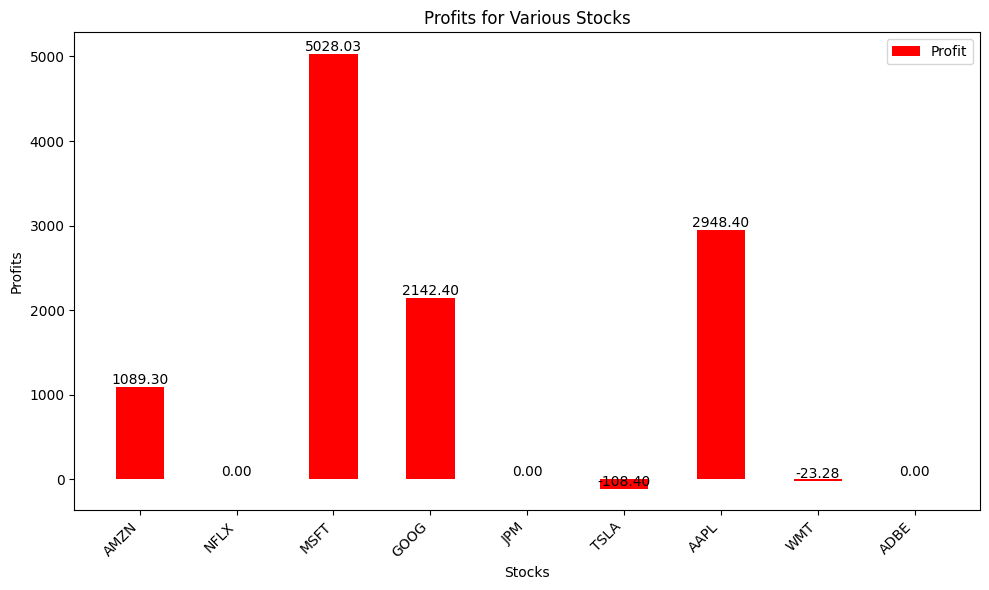

In [3]:
result_tb = {'AMZN': (8.951499938964844, 1089.2997741699219),
 'NFLX': (10.319999694824219, 0.0),
 'MSFT': (21.162370681762695, 5028.031322880153),
 'GOOG': (16.5137939453125, 2142.4023253984633),
 'JPM': (24.40945053100586, 0.0),
 'TSLA': (1.871999979019165, -108.39998722076416),
 'AAPL': (12.388997077941895, 2948.4033881126234),
 'WMT': (15.298918724060059, -23.279009231671807),
 'ADBE': (28.56999969482422, 0.0)}

# Extract the stock names, start values, and end values
stock_names = list(result_tb.keys())
start_values = [values[0] for values in result_tb.values()]
end_values = [values[1] for values in result_tb.values()]

# Plot the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart for end values (profits)
bar_width = 0.5
index = range(len(stock_names))

bars = ax.bar(index, end_values, bar_width, label='Profit', color='r')

# Annotate bars with their values
for bar, profit in zip(bars, end_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        bar.get_height(),  # Y-coordinate: height of the bar
        f'{profit:.2f}',  # Text to display, formatted to 2 decimal places
        ha='center', va='bottom', fontsize=10  # Alignment and font size
    )

# Add labels and title
ax.set_xlabel('Stocks')
ax.set_ylabel('Profits')
ax.set_title('Profits for Various Stocks')
ax.set_xticks(index)
ax.set_xticklabels(stock_names, rotation=45, ha='right')

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [8]:
print("THE AVERAGE RETURN ON STOCKS USING TEXTBLOB SENTIMENT ANALYSIS {}".format(sum(end_values)/len(end_values)))

THE AVERAGE RETURN ON STOCKS USING TEXTBLOB SENTIMENT ANALYSIS 1230.7175349009694


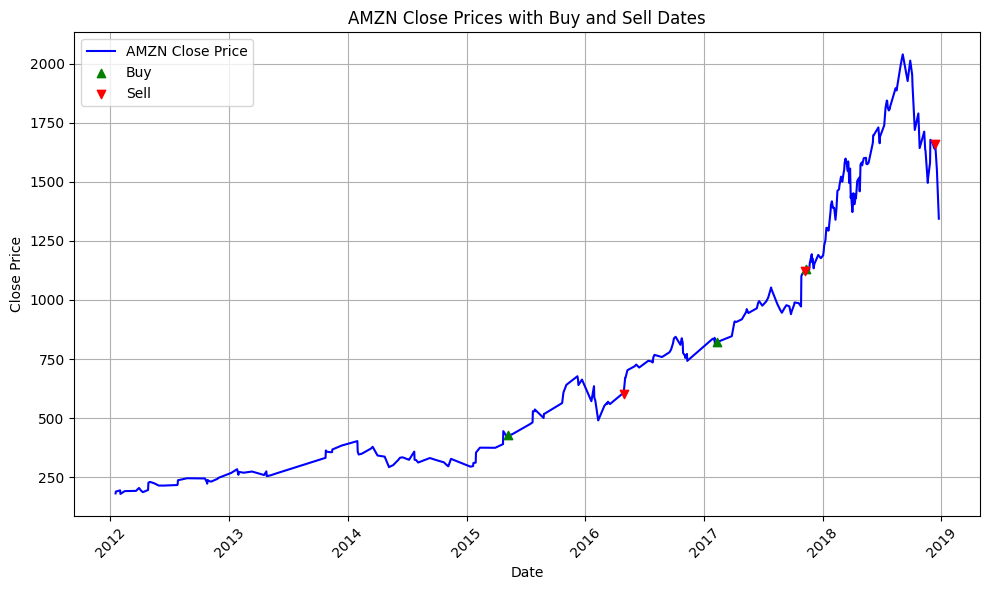

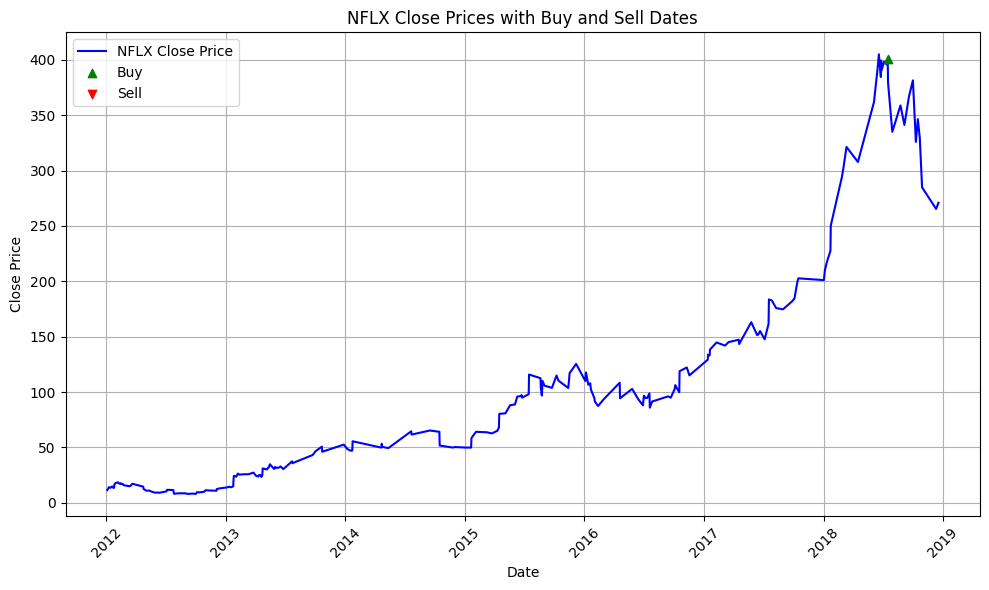

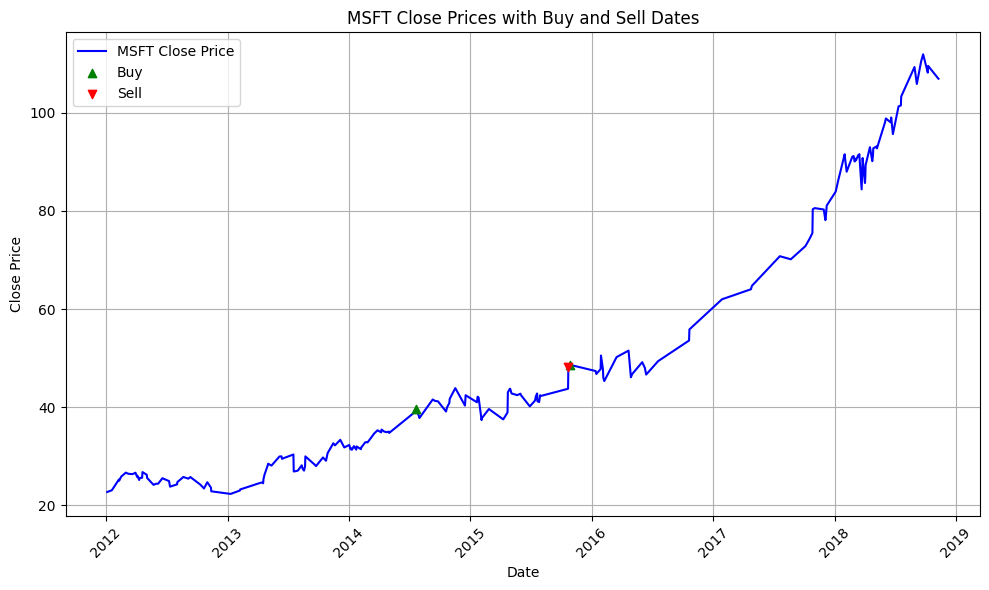

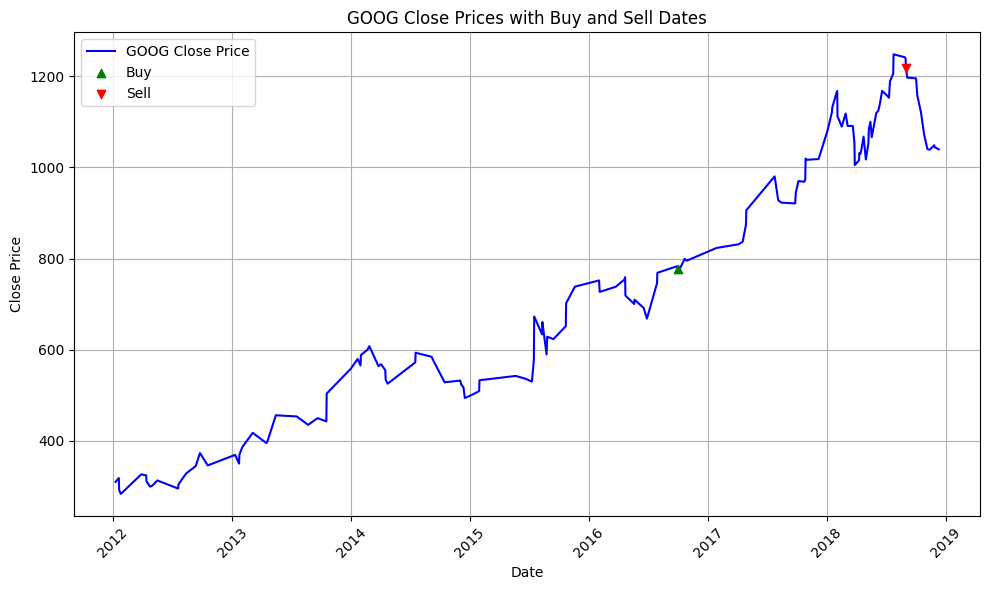

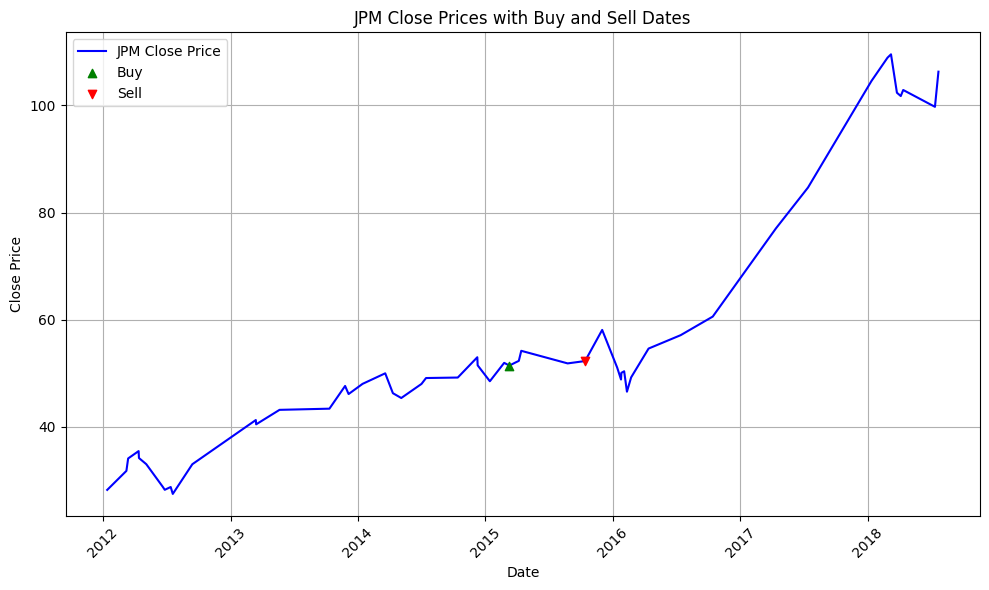

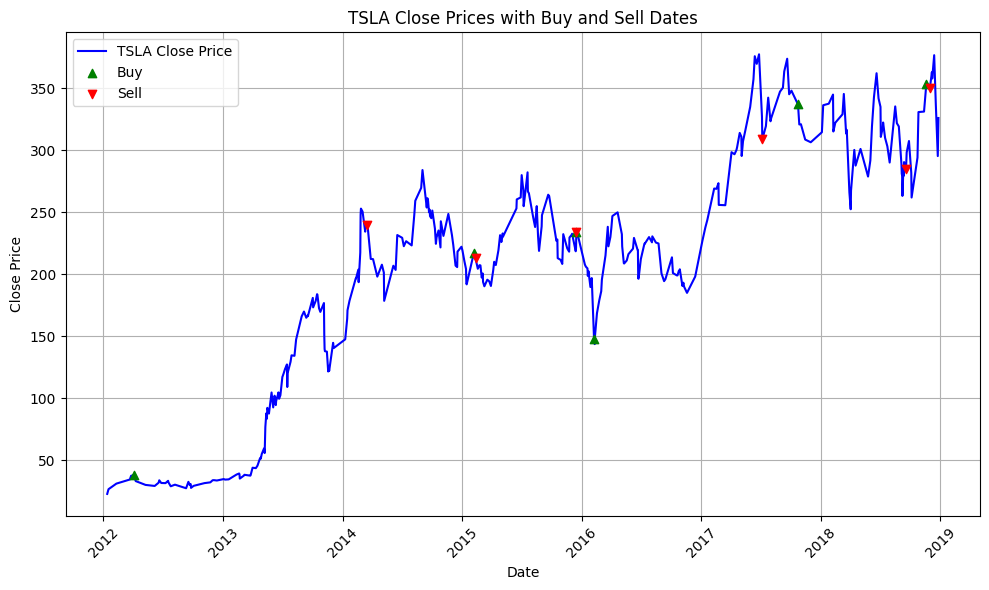

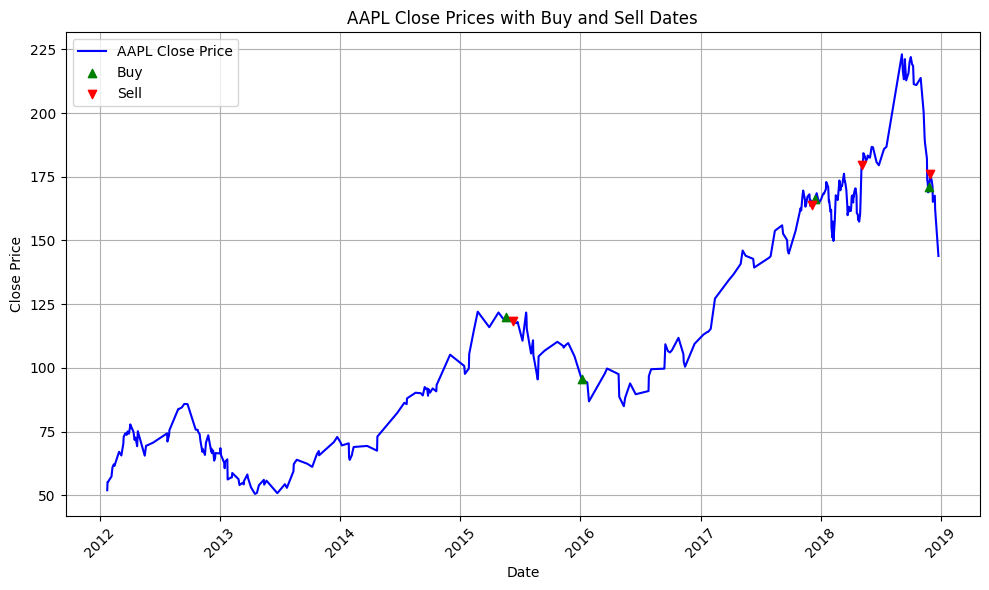

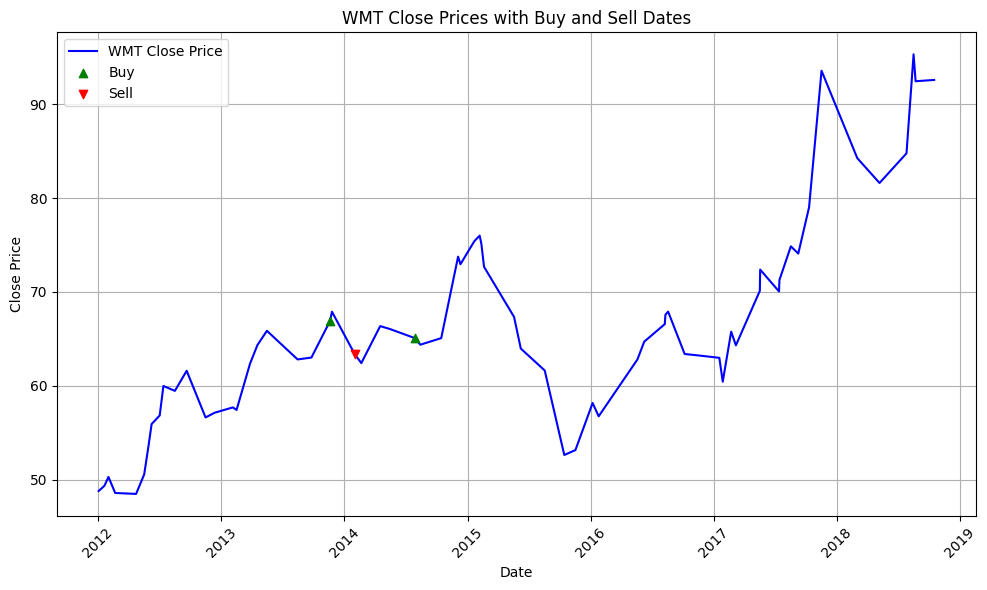

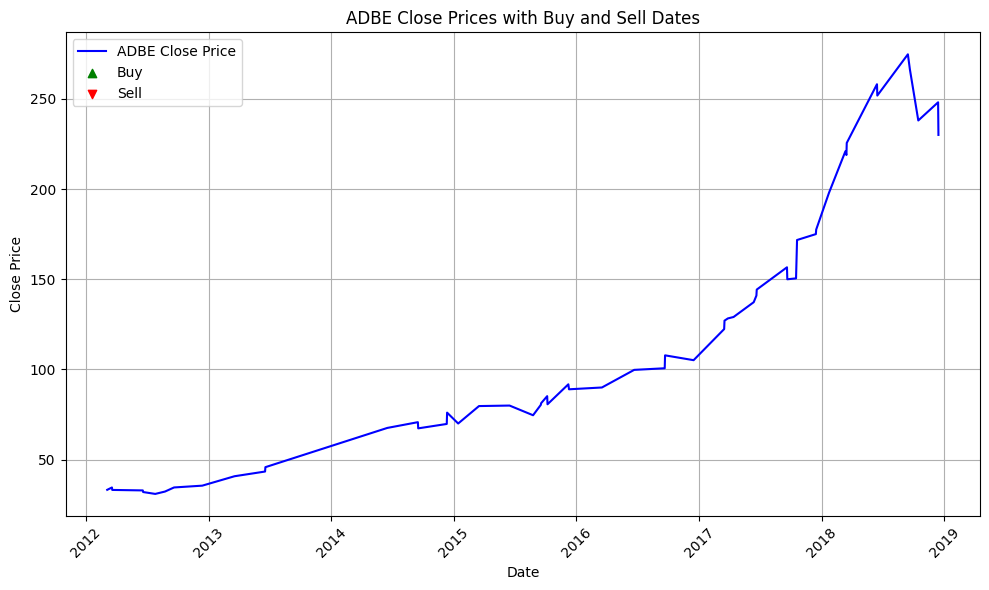

In [11]:

tickers = data.ticker.unique()
for ticker in tickers[:-1]:
  extract_buy_sell_dates_and_plot_tb(data, ticker, '2012-01-01', '2018-12-26')


**3.2 Trading for different tickers using BERT trading strategy**

In [14]:
result={}
for ticker in tickers[:-1]:
  date_sentiment=data[data['ticker'].isin([ticker])]
  date_sentiment=date_sentiment[['date','sentiment_bert']]
  date_sentiment['date']=pd.to_datetime(date_sentiment['date'], format='%Y-%m-%d').dt.date
  date_sentiment=date_sentiment.set_index('date')['sentiment_bert']
  date_sentiment=date_sentiment.to_dict()
  result[ticker] = run_strategy(ticker, start = '2012-01-01', end = '2018-12-26')
#extract_buy_sell_dates_and_plot(data, ticker='GOOG', start_date='2012-01-01', end_date='2018-12-12')

AMZN
Starting Portfolio Value: 100000.00
2012-03-20, Previous Sentiment -1.00, New Sentiment 0.99 BUY CREATE, 9.62
2012-03-21, BUY EXECUTED, Price: 9.62, Cost: 962.50, Comm 0.00
2013-01-29, Previous Sentiment 0.97, New Sentiment -1.00 SELL CREATE, 13.02
2013-01-30, SELL EXECUTED, Price: 14.15, Cost: 962.50, Comm 0.00
2013-01-30, OPERATION PROFIT, GROSS 452.50, NET 452.50
2013-11-13, Previous Sentiment -0.99, New Sentiment 0.90 BUY CREATE, 17.81
2013-11-14, BUY EXECUTED, Price: 17.87, Cost: 1786.95, Comm 0.00
2014-01-06, Previous Sentiment 0.98, New Sentiment -1.00 SELL CREATE, 19.68
2014-01-07, SELL EXECUTED, Price: 19.75, Cost: 1786.95, Comm 0.00
2014-01-07, OPERATION PROFIT, GROSS 188.25, NET 188.25
2014-03-18, Previous Sentiment -0.96, New Sentiment 0.96 BUY CREATE, 18.94
2014-03-19, BUY EXECUTED, Price: 18.94, Cost: 1893.85, Comm 0.00
2014-04-02, Previous Sentiment 0.96, New Sentiment 0.22 SELL CREATE, 17.10
2014-04-03, SELL EXECUTED, Price: 17.09, Cost: 1893.85, Comm 0.00
2014-04-

<ipython-input-8-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


2012-01-26, Previous Sentiment -0.99, New Sentiment 0.30 BUY CREATE, 16.57
2012-01-27, BUY EXECUTED, Price: 16.54, Cost: 1654.29, Comm 0.00
2012-02-21, Previous Sentiment 0.69, New Sentiment -1.00 SELL CREATE, 16.77
2012-02-22, SELL EXECUTED, Price: 16.42, Cost: 1654.29, Comm 0.00
2012-02-22, OPERATION PROFIT, GROSS -12.71, NET -12.71
2012-03-21, Previous Sentiment -0.97, New Sentiment 0.96 BUY CREATE, 17.16
2012-03-22, BUY EXECUTED, Price: 17.15, Cost: 1714.71, Comm 0.00
2012-04-23, Previous Sentiment 0.96, New Sentiment -0.99 SELL CREATE, 14.55
2012-04-24, SELL EXECUTED, Price: 12.36, Cost: 1714.71, Comm 0.00
2012-04-24, OPERATION PROFIT, GROSS -478.71, NET -478.71
2012-09-21, Previous Sentiment -1.00, New Sentiment 0.88 BUY CREATE, 8.26
2012-09-24, BUY EXECUTED, Price: 8.12, Cost: 812.29, Comm 0.00
2012-10-01, Previous Sentiment 0.88, New Sentiment -0.97 SELL CREATE, 8.01
2012-10-02, SELL EXECUTED, Price: 8.06, Cost: 812.29, Comm 0.00
2012-10-02, OPERATION PROFIT, GROSS -5.86, NET -

<ipython-input-8-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


2013-05-03, Previous Sentiment -1.00, New Sentiment 0.97 BUY CREATE, 27.39
2013-05-06, BUY EXECUTED, Price: 27.34, Cost: 2733.67, Comm 0.00
2014-01-23, Previous Sentiment 0.97, New Sentiment -0.99 SELL CREATE, 30.14
2014-01-24, SELL EXECUTED, Price: 31.30, Cost: 2733.67, Comm 0.00
2014-01-24, OPERATION PROFIT, GROSS 396.42, NET 396.42
2014-02-25, Previous Sentiment -0.95, New Sentiment 0.57 BUY CREATE, 31.61
2014-02-26, BUY EXECUTED, Price: 31.65, Cost: 3164.51, Comm 0.00
2014-04-08, Previous Sentiment 1.00, New Sentiment -0.32 SELL CREATE, 33.53
2014-04-09, SELL EXECUTED, Price: 33.62, Cost: 3164.51, Comm 0.00
2014-04-09, OPERATION PROFIT, GROSS 197.89, NET 197.89
2014-07-22, Previous Sentiment -1.00, New Sentiment 0.49 BUY CREATE, 38.02
2014-07-23, BUY EXECUTED, Price: 38.54, Cost: 3854.23, Comm 0.00
2014-07-31, Previous Sentiment 0.97, New Sentiment -0.99 SELL CREATE, 36.60
2014-08-01, SELL EXECUTED, Price: 36.64, Cost: 3854.23, Comm 0.00
2014-08-01, OPERATION PROFIT, GROSS -189.96,

...

<ipython-input-8-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


2012-05-17, Previous Sentiment -0.90, New Sentiment -0.28 BUY CREATE, 15.85
2012-05-18, BUY EXECUTED, Price: 15.90, Cost: 1590.16, Comm 0.00
2012-08-16, Previous Sentiment 0.53, New Sentiment -0.98 SELL CREATE, 18.64
2012-08-17, SELL EXECUTED, Price: 18.71, Cost: 1590.16, Comm 0.00
2012-08-17, OPERATION PROFIT, GROSS 280.96, NET 280.96
2013-11-25, Previous Sentiment -1.00, New Sentiment -0.06 BUY CREATE, 21.29
2013-11-26, BUY EXECUTED, Price: 21.29, Cost: 2129.11, Comm 0.00
2014-01-31, Previous Sentiment -0.06, New Sentiment -1.00 SELL CREATE, 19.88
2014-02-03, SELL EXECUTED, Price: 19.75, Cost: 2129.11, Comm 0.00
2014-02-03, OPERATION PROFIT, GROSS -154.00, NET -154.00
2014-04-17, Previous Sentiment -0.98, New Sentiment 0.29 BUY CREATE, 20.81
2014-04-21, BUY EXECUTED, Price: 20.74, Cost: 2074.14, Comm 0.00
2014-05-15, Previous Sentiment 0.29, New Sentiment -1.00 SELL CREATE, 20.71
2014-05-16, SELL EXECUTED, Price: 20.76, Cost: 2074.14, Comm 0.00
2014-05-16, OPERATION PROFIT, GROSS 1.7

<ipython-input-8-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


2012-07-26, Previous Sentiment -1.00, New Sentiment 0.12 BUY CREATE, 30.95
2012-07-27, BUY EXECUTED, Price: 31.26, Cost: 3126.00, Comm 0.00
2012-08-24, Previous Sentiment 0.12, New Sentiment -1.00 SELL CREATE, 32.26
2012-08-27, SELL EXECUTED, Price: 32.47, Cost: 3126.00, Comm 0.00
2012-08-27, OPERATION PROFIT, GROSS 121.00, NET 121.00
2012-09-20, Previous Sentiment -1.00, New Sentiment -0.25 BUY CREATE, 34.53
2012-09-21, BUY EXECUTED, Price: 34.36, Cost: 3436.00, Comm 0.00
2015-08-25, Previous Sentiment 0.99, New Sentiment 0.29 SELL CREATE, 74.57
2015-08-26, SELL EXECUTED, Price: 76.14, Cost: 3436.00, Comm 0.00
2015-08-26, OPERATION PROFIT, GROSS 4178.00, NET 4178.00
2015-09-18, Previous Sentiment -1.00, New Sentiment 0.99 BUY CREATE, 81.25
2015-09-21, BUY EXECUTED, Price: 81.42, Cost: 8142.00, Comm 0.00
2017-04-13, Previous Sentiment 1.00, New Sentiment -0.98 SELL CREATE, 129.05
2017-04-17, SELL EXECUTED, Price: 129.69, Cost: 8142.00, Comm 0.00
2017-04-17, OPERATION PROFIT, GROSS 4827

<ipython-input-8-af34596c294d>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_ticker['Close'][0]), (end - start)


Results of the simulation strategy

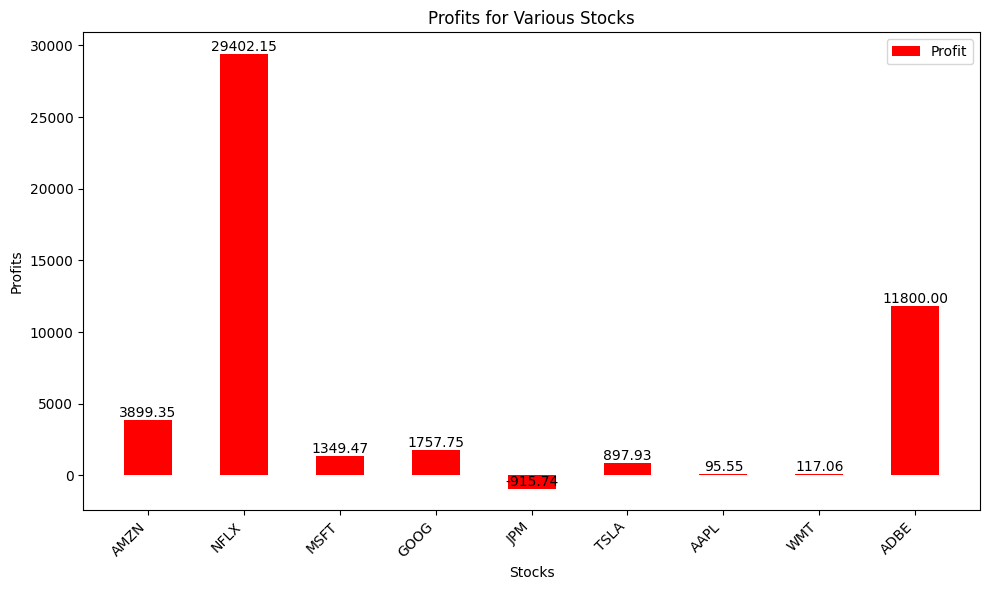

In [9]:
import matplotlib.pyplot as plt

result = {
    'AMZN': (8.951499938964844, 3899.3507385253906),
    'NFLX': (10.319999694824219, 29402.14500427246),
    'MSFT': (21.120098114013672, 1349.471791769378),
    'GOOG': (16.5137939453125, 1757.754621914457),
    'JPM': (24.409446716308594, -915.7382654473768),
    'TSLA': (1.871999979019165, 897.9332804679871),
    'AAPL': (12.388998031616211, 95.54641919284768),
    'WMT': (15.298920631408691, 117.06135291903047),
    'ADBE': (28.56999969482422, 11800.000953674316)
}

# Extract the stock names, start values, and end values
stock_names = list(result.keys())
start_values = [values[0] for values in result.values()]
end_values = [values[1] for values in result.values()]

# Plot the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart for end values (profits)
bar_width = 0.5
index = range(len(stock_names))

bars = ax.bar(index, end_values, bar_width, label='Profit', color='r')

# Annotate bars with their values
for bar, profit in zip(bars, end_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        bar.get_height(),  # Y-coordinate: height of the bar
        f'{profit:.2f}',  # Text to display, formatted to 2 decimal places
        ha='center', va='bottom', fontsize=10  # Alignment and font size
    )

# Add labels and title
ax.set_xlabel('Stocks')
ax.set_ylabel('Profits')
ax.set_title('Profits for Various Stocks')
ax.set_xticks(index)
ax.set_xticklabels(stock_names, rotation=45, ha='right')

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [11]:
print("THE AVERAGE RETURN ON STOCKS USING BERT SENTIMENT ANALYSIS: {}".format(sum(end_values)/len(end_values)))

THE AVERAGE RETURN ON STOCKS USING BERT SENTIMENT ANALYSIS: 5378.169544143166


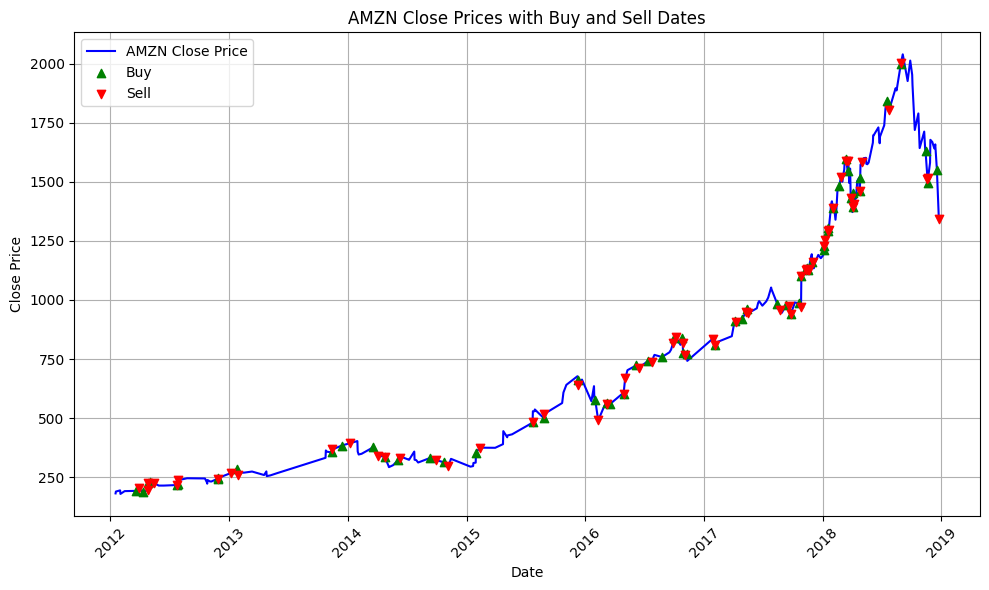

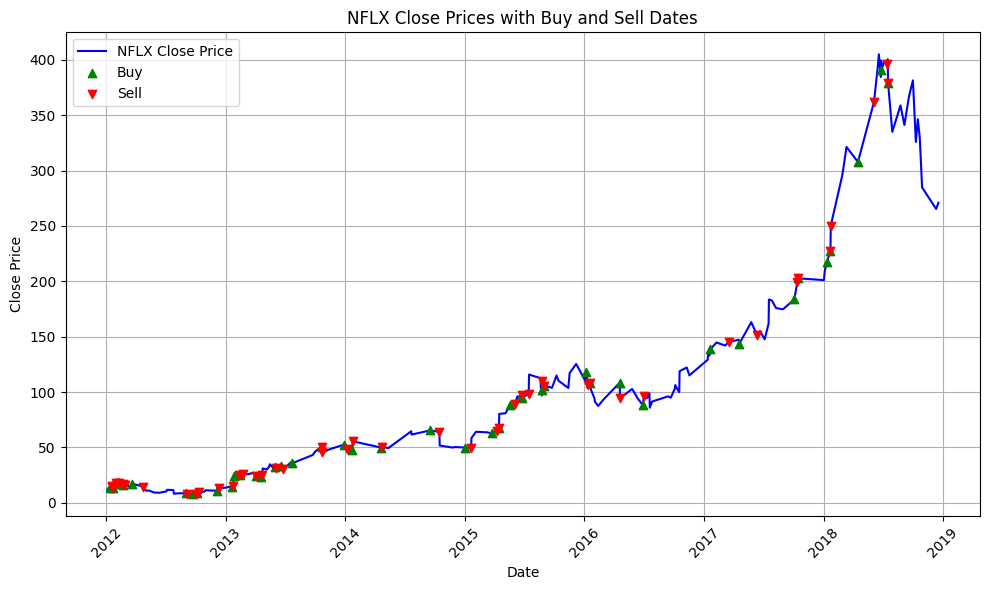

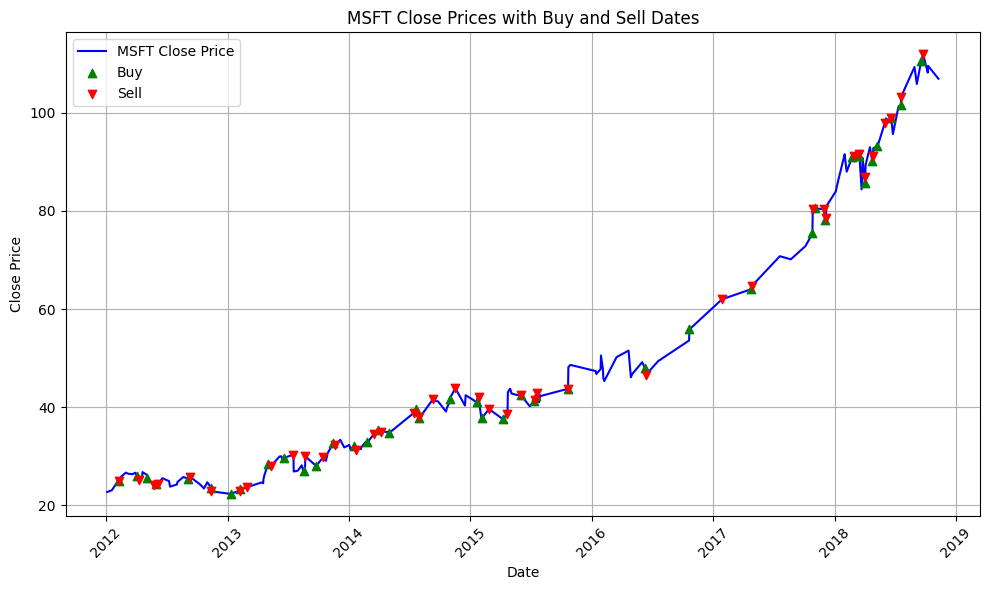

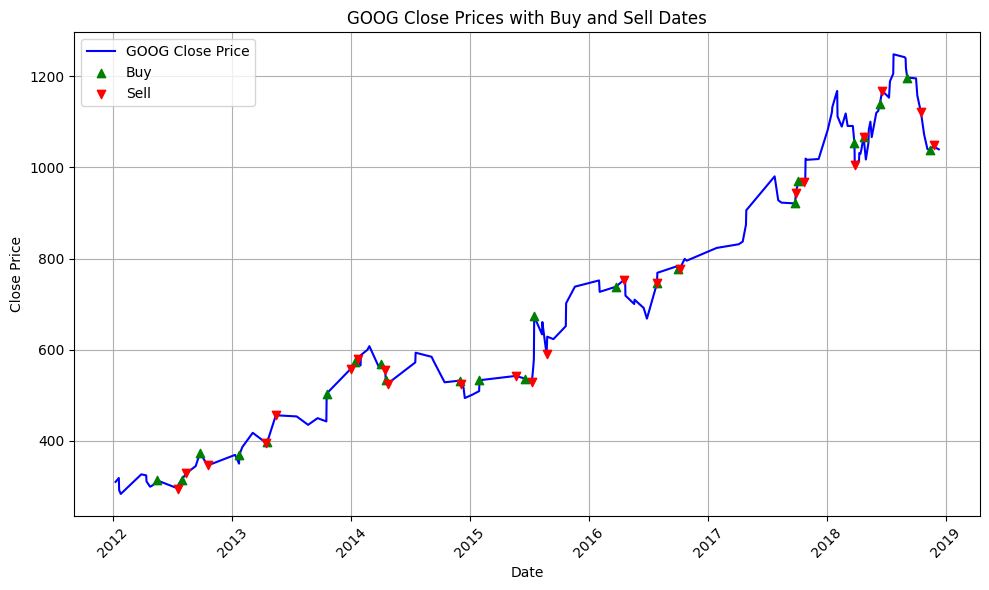

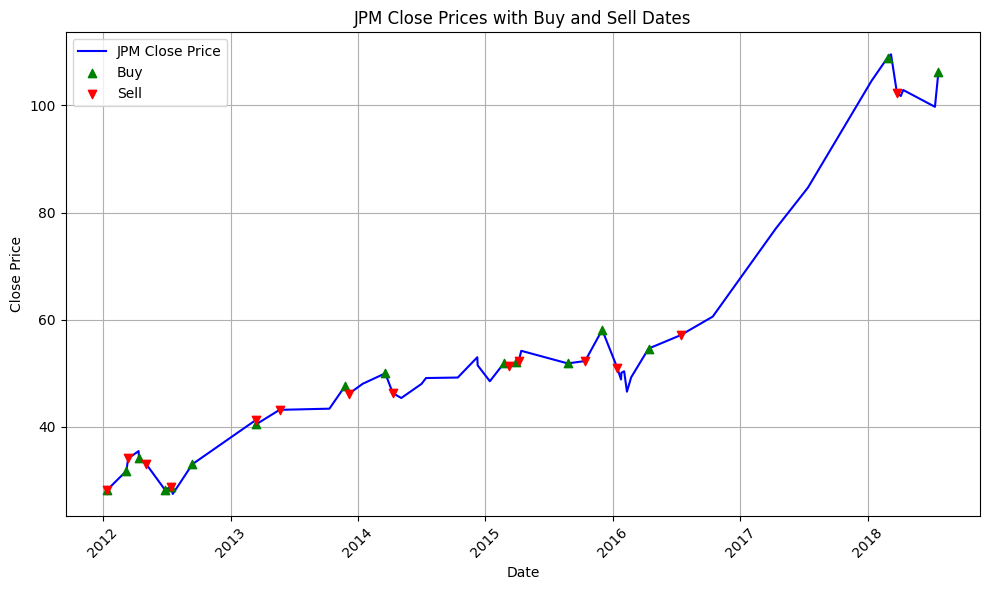

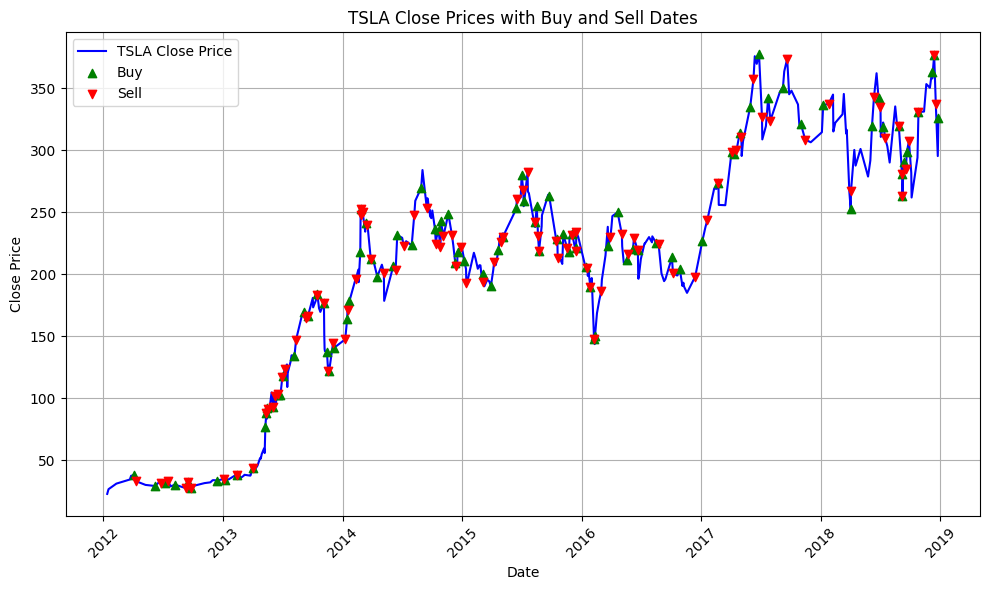

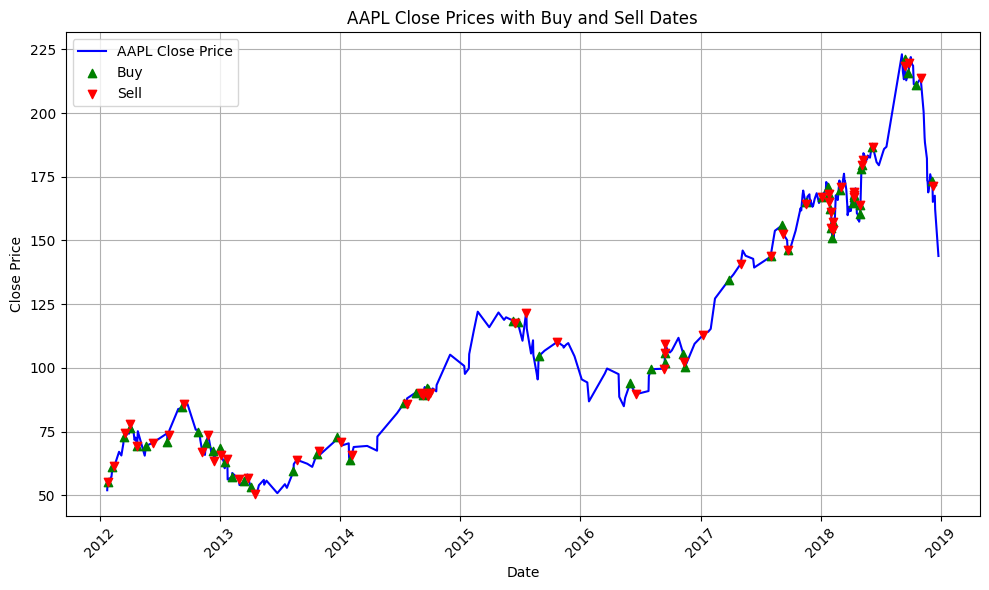

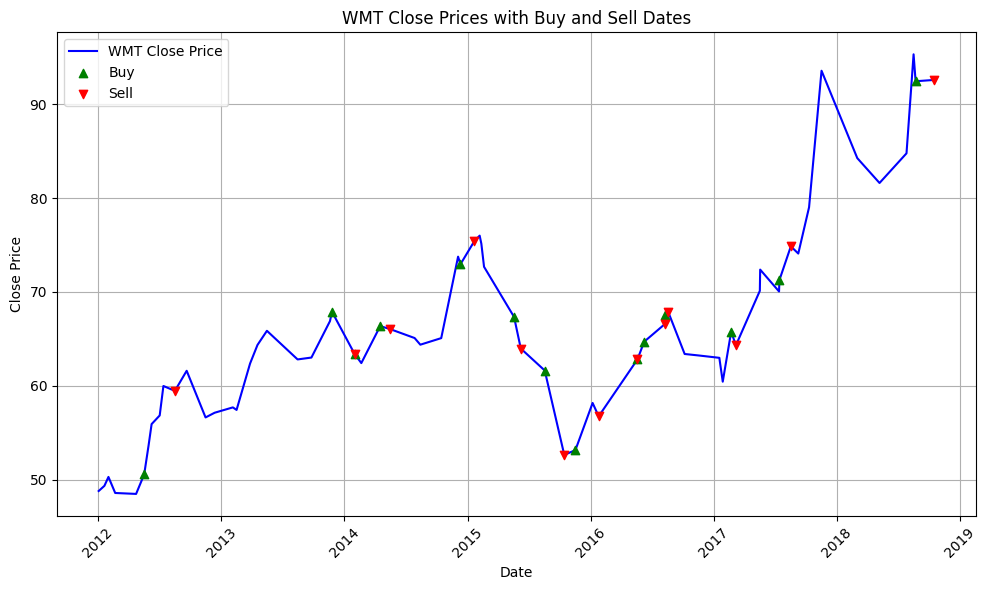

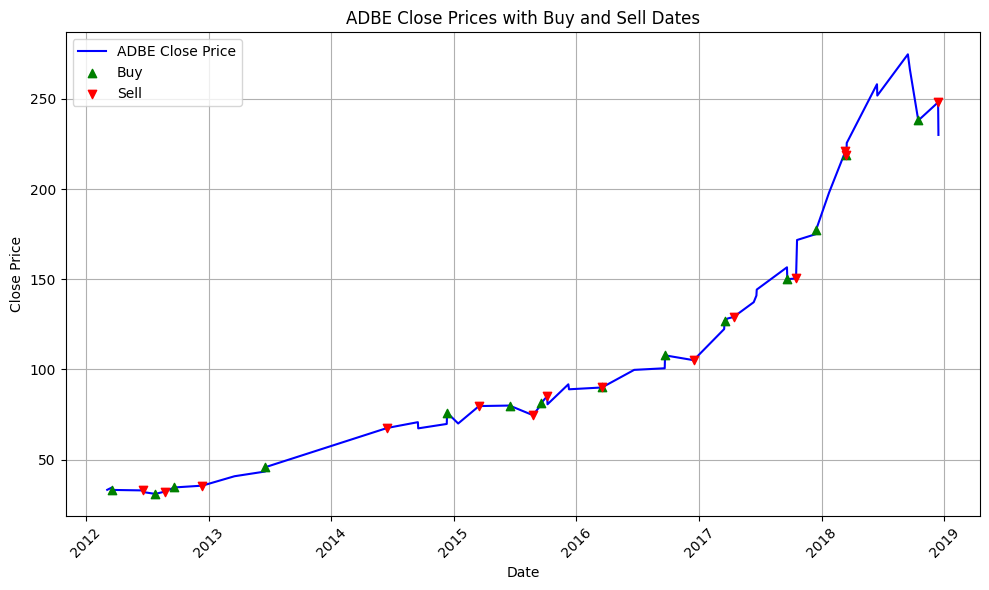

In [5]:
tickers = data.ticker.unique()
for ticker in tickers[:-1]:
  extract_buy_sell_dates_and_plot(data, ticker, '2012-01-01', '2018-12-26')


Conclusion:
The average returns using a BERT model is significantly higher than TEXTBLOB model, thus performing better while recommending a trading strategy.


**Scope for further research:**
Although the models were trained on general text phrases, they have demonstrated the ability to generate profits over time. However, one promising avenue for future research is to customize these models by training them specifically on financial data. By incorporating domain-specific language, such as news articles, earnings reports, financial statements, and market commentary, the models could improve their understanding of financial sentiment. This would potentially enhance their ability to make more accurate predictions about market movements, leading to better buy and sell signals. Tailoring the models to the intricacies of financial language may help capture subtle nuances in sentiment that are often missed by models trained on general text, thus providing more precise insights for investors and traders.
